In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [37]:
df =pd.read_csv("titanic_toy.csv")

In [38]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [39]:
df.describe()

,Age,Fare,Family,Survived
count,714.000000,846.000000,891.000000,891.000000
mean,29.699118,32.279338,0.904602,0.383838
std,14.526497,50.305796,1.613459,0.486592
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.206250,1.000000,1.000000
max,80.000000,512.329200,10.000000,1.000000


In [40]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [41]:
X = df.drop(columns='Survived')
y = df['Survived']

In [42]:
X.shape

(891, 3)

In [43]:
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [44]:
X_train.shape

(712, 3)

In [45]:
X_train.isnull().mean()*100

Age       20.786517
Fare       5.056180
Family     0.000000
dtype: float64

In [46]:
X_train['Age_arbitary'] = X_train['Age'].fillna(99)
X_train['Fare_arbitary'] = X_train['Age'].fillna(999)

In [47]:
X_train

,Age,Fare,Family,Age_arbitary,Fare_arbitary
30,40.0,27.7208,0,40.0,40.0
10,4.0,16.7000,2,4.0,4.0
873,47.0,9.0000,0,47.0,47.0
182,9.0,31.3875,6,9.0,9.0
876,20.0,9.8458,0,20.0,20.0
...,...,...,...,...,...
534,30.0,8.6625,0,30.0,30.0
584,NaN,8.7125,0,99.0,999.0
493,71.0,49.5042,0,71.0,71.0
527,NaN,221.7792,0,99.0,999.0


<Axes: ylabel='Density'>

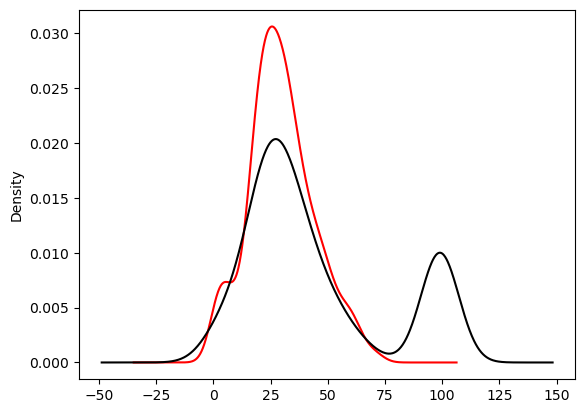

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind = 'kde' , color = 'red')
X_train['Age_arbitary'].plot(kind = 'kde' , color = 'black')


<Axes: ylabel='Density'>

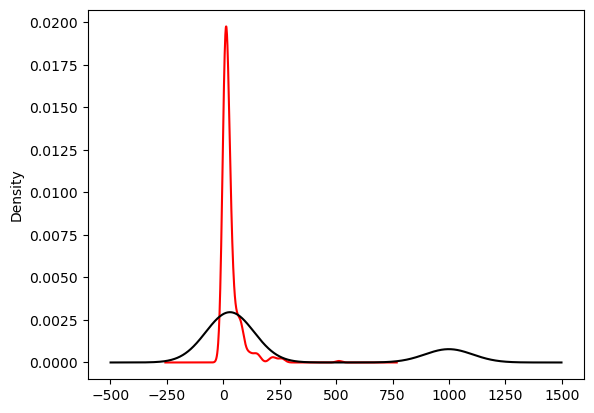

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind = 'kde' , color = 'red')
X_train['Fare_arbitary'].plot(kind = 'kde' , color = 'black')

In [50]:
print(X_train['Age'].var()) 
print(X_train['Age_arbitary'].var()) 

204.3495133904614
951.7275570187172


In [51]:
print(X_train['Fare'].var()) 
print(X_train['Fare_arbitary'].var()) 

2448.197913706318
155054.41209691283


In [52]:
X_train.cov()

,Age,Fare,Family,Age_arbitary,Fare_arbitary
Age,204.349513,70.719262,-6.498901,204.349513,204.349513
Fare,70.719262,2448.197914,17.258917,-101.671097,-2146.736242
Family,-6.498901,17.258917,2.735252,-7.387287,-36.529656
Age_arbitary,204.349513,-101.671097,-7.387287,951.727557,11223.095428
Fare_arbitary,204.349513,-2146.736242,-36.529656,11223.095428,155054.412097


In [53]:
X_train.corr()

,Age,Fare,Family,Age_arbitary,Fare_arbitary
Age,1.000000,0.092644,-0.299113,1.000000,1.000000
Fare,0.092644,1.000000,0.208268,-0.066273,-0.109742
Family,-0.299113,0.208268,1.000000,-0.144787,-0.056093
Age_arbitary,1.000000,-0.066273,-0.144787,1.000000,0.923877
Fare_arbitary,1.000000,-0.109742,-0.056093,0.923877,1.000000


#### from sklearn

In [54]:
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [61]:
imputer1 = SimpleImputer(strategy='constant' , fill_value=99.0)
imputer2 = SimpleImputer(strategy='constant' , fill_value=999.9)


In [62]:
trf =ColumnTransformer([
    ('imputer1' , imputer1 ,['Age']),
    ('imputer2' , imputer2 , ['Fare'])
],remainder='passthrough')

In [63]:
trf.fit(X_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99.0,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999.9,
                                               strategy='constant'),
                                 ['Fare'])])

In [64]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [65]:
X_train

array([[99.    , 23.25  ,  2.    ],
       [30.    , 56.9292,  0.    ],
       [34.    , 10.5   ,  0.    ],
       ...,
       [21.    , 73.5   ,  0.    ],
       [99.    ,  7.55  ,  0.    ],
       [21.    ,  8.05  ,  0.    ]])